## Step 1: Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from gensim.models import Word2Vec

## Step 2: Load the SMS Spam Dataset

In [4]:
df = pd.read_csv("spam.csv", encoding="latin-1")

In [5]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [6]:
df.shape

(5572, 5)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 677.1 KB


In [8]:
df = df[["v1", "v2"]]

df.columns = ["label", "message"]

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
df["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

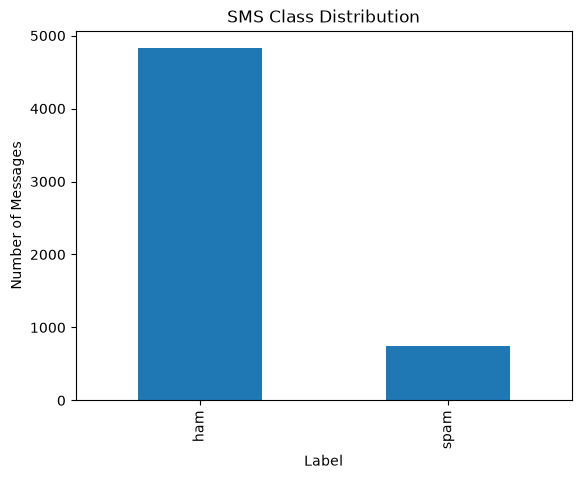

In [10]:
df["label"].value_counts().plot(kind="bar")

plt.title("SMS Class Distribution")
plt.xlabel("Label")
plt.ylabel("Number of Messages")
plt.show()

In [11]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [12]:
df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape:", df.shape)

Dataset shape: (5169, 2)


In [13]:
df["target"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

df.head()

,label,message,target
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


## Step 3: Train/Test Split

In [14]:
X = df["message"]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4135
Testing samples: 1034


In [15]:
print("Training distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True))

Training distribution:
target
0    0.873761
1    0.126239
Name: proportion, dtype: float64

Testing distribution:
target
0    0.873308
1    0.126692
Name: proportion, dtype: float64


## Step 4: Text Preprocessing

In [16]:
import re

In [17]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [18]:
sample = X_train.iloc[0]

print("Original:")
print(sample)

print("\nProcessed:")
print(preprocess_text(sample))

Original:
Cool. So how come you havent been wined and dined before?

Processed:
cool so how come you havent been wined and dined before


In [19]:
X_train_clean = X_train.apply(preprocess_text)
X_test_clean = X_test.apply(preprocess_text)

In [20]:
pd.DataFrame({
    "original": X_train.head(),
    "processed": X_train_clean.head()
})

,original,processed
331,Cool. So how come you havent been wined and di...,cool so how come you havent been wined and din...
383,Huh so late... Fr dinner?,huh so late fr dinner
574,my ex-wife was not able to have kids. Do you w...,my ex wife was not able to have kids do you wa...
1346,Hope ur head doesn't hurt 2 much ! Am ploughin...,hope ur head doesn t hurt 2 much am ploughing ...
1070,Ryder unsold.now gibbs.,ryder unsold now gibbs


## Step 5: Tokenize the Training Corpus

In [21]:
train_tokens = X_train_clean.apply(str.split).tolist()
test_tokens = X_test_clean.apply(str.split).tolist()

In [22]:
print(train_tokens[:3])

[['cool', 'so', 'how', 'come', 'you', 'havent', 'been', 'wined', 'and', 'dined', 'before'], ['huh', 'so', 'late', 'fr', 'dinner'], ['my', 'ex', 'wife', 'was', 'not', 'able', 'to', 'have', 'kids', 'do', 'you', 'want', 'kids', 'one', 'day']]


In [23]:
print("Number of training sentences:", len(train_tokens))
print("First sentence:", train_tokens[0])
print("Number of words in first sentence:", len(train_tokens[0]))

Number of training sentences: 4135
First sentence: ['cool', 'so', 'how', 'come', 'you', 'havent', 'been', 'wined', 'and', 'dined', 'before']
Number of words in first sentence: 11


## Step 6: Train Our Word2Vec Model

In [24]:
word2vec_model = Word2Vec(
    sentences=train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    negative=10,
    epochs=20,
    seed=42
)

## Step 7: Inspect the Learned Vocabulary

In [25]:
print("Vocabulary size:", len(word2vec_model.wv))

Vocabulary size: 3406


In [26]:
print(word2vec_model.wv.index_to_key[:30])

['i', 'you', 'to', 'a', 'the', 'u', 'and', 'in', 'is', 'me', 'it', 'for', 'my', 'your', 's', 'that', 'of', 'have', '2', 'call', 'on', 'are', 'now', 'can', 'so', 't', 'm', 'not', 'but', 'we']


In [27]:
word = "free"

vector = word2vec_model.wv[word]

print("Vector shape:", vector.shape)
print("Vector:")
print(vector)

Vector shape: (100,)
Vector:
[ 0.10823371  0.02163275  0.261955    0.3988065  -0.35992098  0.49047986
 -0.01900946  0.1422678  -0.7379941  -0.18530685 -0.81929946 -0.22670297
 -0.41961974  0.15835714  0.05927333 -0.7193121  -0.27087712 -0.55422014
 -0.5277696   0.50735986 -0.44858626 -0.08912227 -0.35723224  0.47981343
 -0.3404437  -0.503098   -0.13902211 -0.57113475 -0.34781805 -0.04041771
  0.1581759   0.16920315  0.09722139  0.35372552 -0.12736712  0.07053655
  0.4706156  -0.9096492   0.1774282   0.47269848  0.2470449  -0.44536638
  0.14502624 -0.0212137  -0.15227033 -0.4828885   0.5984411   0.214619
 -0.00729772 -0.66341984  0.06580444 -0.48552752  0.7700969   0.37016016
  0.04258506 -0.13436241 -0.1613955   0.31303933  0.09217527  0.787553
  0.53943664 -0.8825042   0.40752515  0.18232764 -0.5515471   0.31681135
 -0.2824072  -0.42141384 -0.44609803 -0.22705619  0.10305184  0.07356352
 -0.02986684 -0.29697546 -0.12891115  0.0273951   0.57398933  0.21199074
 -0.6828494  -0.27176172  

## Step 8: Find Similar Words

In [28]:
word2vec_model.wv.most_similar("free", topn=10)

[('bluetooth', 0.6387682557106018),
 ('digital', 0.6349598169326782),
 ('mobilesdirect', 0.631140410900116),
 ('deliveredtomorrow', 0.6296759843826294),
 ('delivered', 0.6272270083427429),
 ('yer', 0.6262403130531311),
 ('sonyericsson', 0.6251155138015747),
 ('flag', 0.6248212456703186),
 ('unlimited', 0.6216296553611755),
 ('official', 0.617500901222229)]

In [29]:
word2vec_model.wv.most_similar("call", topn=10)

[('0800', 0.6196628212928772),
 ('08712300220', 0.603617250919342),
 ('matches', 0.5992277264595032),
 ('09056242159', 0.5943605899810791),
 ('quoting', 0.5942367315292358),
 ('landline', 0.5915431380271912),
 ('542', 0.5906299948692322),
 ('0578', 0.5882046818733215),
 ('6hl', 0.5881279706954956),
 ('w1j', 0.584610641002655)]

In [30]:
word2vec_model.wv.most_similar("money", topn=10)

[('jay', 0.741644024848938),
 ('alcohol', 0.7272821664810181),
 ('cleaning', 0.7227351665496826),
 ('worries', 0.7202422022819519),
 ('batch', 0.7188107371330261),
 ('rent', 0.71351158618927),
 ('shut', 0.7121613025665283),
 ('tyler', 0.7054260969161987),
 ('sept', 0.7051120400428772),
 ('banks', 0.705020010471344)]

In [31]:
word2vec_model.wv.most_similar("home", topn=10)

[('chillin', 0.6972731947898865),
 ('machan', 0.6927050948143005),
 ('nope', 0.6831324100494385),
 ('funeral', 0.676299512386322),
 ('reached', 0.6619255542755127),
 ('reaching', 0.6576815247535706),
 ('engin', 0.6558133363723755),
 ('arts', 0.6552407741546631),
 ('calicut', 0.6534960269927979),
 ('gym', 0.65064537525177)]

## Step 9: Direct Cosine Similarity

In [32]:
word2vec_model.wv.similarity("free", "money")

np.float32(0.18205395)

In [33]:
word2vec_model.wv.similarity("home", "house")

np.float32(0.4842598)

In [34]:
pairs = [
    ("free", "money"),
    ("free", "home"),
    ("call", "phone"),
    ("home", "house")
]

for word1, word2 in pairs:
    if word1 in word2vec_model.wv and word2 in word2vec_model.wv:
        similarity = word2vec_model.wv.similarity(word1, word2)
        print(f"{word1:>8} ↔ {word2:<8}: {similarity:.4f}")

    free ↔ money   : 0.1821
    free ↔ home    : 0.2185
    call ↔ phone   : 0.3114
    home ↔ house   : 0.4843


## Glove


In [35]:
import gensim.downloader as api

In [36]:
glove_model = api.load("glove-wiki-gigaword-100")

[==================================================] 100.0% 128.1/128.1MB downloaded


In [37]:
print("Vocabulary size:", len(glove_model))
print("Embedding dimension:", glove_model.vector_size)

Vocabulary size: 400000
Embedding dimension: 100


In [38]:
glove_model["free"]

array([ 0.16057  ,  0.1303   ,  0.07715  , -0.69427  ,  0.49514  ,
        0.46282  ,  0.31438  , -0.010989 , -0.18431  , -0.27871  ,
        0.20346  ,  0.22696  ,  0.043523 , -0.093614 ,  0.43478  ,
        0.26122  ,  0.35743  , -0.1084   , -0.71991  , -0.54551  ,
        0.13281  ,  0.27251  ,  0.10817  ,  0.0076803,  0.33751  ,
        0.21586  , -0.29579  , -0.68925  ,  0.10807  ,  0.075162 ,
       -0.29155  ,  1.3457   , -0.18036  ,  0.085421 ,  0.96463  ,
       -0.12585  , -0.085178 ,  0.60349  , -0.77539  , -0.25928  ,
       -0.23715  ,  0.072939 ,  0.17343  , -0.15102  ,  0.033241 ,
       -0.70268  , -0.32607  , -0.48482  ,  0.45782  , -0.10718  ,
        0.21778  ,  0.55233  , -0.66013  ,  0.052084 , -0.19624  ,
       -2.2203   ,  0.12812  , -0.21023  ,  2.7278   ,  0.016715 ,
       -0.19848  ,  0.096693 , -0.59123  , -0.56204  ,  0.90229  ,
       -0.02034  ,  0.6628   , -0.41542  ,  0.045779 , -0.80634  ,
       -0.14747  , -0.53702  ,  0.24234  , -0.2962   ,  0.1439

In [39]:
glove_model["free"].shape

(100,)

In [40]:
glove_model.most_similar("free", topn=10)

[('through', 0.7120156288146973),
 ('without', 0.7030160427093506),
 ('allowed', 0.702085554599762),
 ('access', 0.6976132392883301),
 ('right', 0.6899128556251526),
 ('make', 0.6881558895111084),
 ('for', 0.6821370720863342),
 ('return', 0.6796891689300537),
 ('get', 0.679097592830658),
 ('giving', 0.6790494918823242)]

In [41]:
glove_model.most_similar("money", topn=10)

[('funds', 0.8508071303367615),
 ('cash', 0.848483681678772),
 ('fund', 0.7594833374023438),
 ('paying', 0.7415367364883423),
 ('pay', 0.740767240524292),
 ('paid', 0.7344814538955688),
 ('get', 0.733965277671814),
 ('tax', 0.7233580946922302),
 ('financing', 0.721599280834198),
 ('keep', 0.7185224890708923)]

In [42]:
glove_model.most_similar("phone", topn=10)

[('telephone', 0.9113394021987915),
 ('cellphone', 0.8122148513793945),
 ('phones', 0.8030568957328796),
 ('mobile', 0.7307462692260742),
 ('mail', 0.7292180061340332),
 ('internet', 0.7269454002380371),
 ('messages', 0.7129441499710083),
 ('wireless', 0.7091723084449768),
 ('telephones', 0.7049247622489929),
 ('cellular', 0.6969102621078491)]

In [43]:
pairs = [
    ("free", "money"),
    ("free", "home"),
    ("call", "phone"),
    ("home", "house")
]

for word1, word2 in pairs:
    similarity = glove_model.similarity(word1, word2)
    print(f"{word1:>8} ↔ {word2:<8}: {similarity:.4f}")

    free ↔ money   : 0.5869
    free ↔ home    : 0.6004
    call ↔ phone   : 0.6489
    home ↔ house   : 0.6720


## Step 10: Visualize Word2Vec Embeddings with PCA

In [44]:
from sklearn.decomposition import PCA

In [45]:
words = [
    "free", "money", "cash", "win", "prize",
    "call", "phone", "mobile", "text",
    "home", "house", "family", "love",
    "good", "great", "happy", "sorry",
    "work", "time", "today"
]

# Keep only words that exist in our vocabulary
words = [word for word in words if word in word2vec_model.wv]

print("Words available:", len(words))
print(words)

Words available: 20
['free', 'money', 'cash', 'win', 'prize', 'call', 'phone', 'mobile', 'text', 'home', 'house', 'family', 'love', 'good', 'great', 'happy', 'sorry', 'work', 'time', 'today']


In [46]:
word_vectors = np.array([
    word2vec_model.wv[word]
    for word in words
])

print("Vector matrix shape:", word_vectors.shape)

Vector matrix shape: (20, 100)


In [47]:
pca = PCA(n_components=2)

vectors_2d = pca.fit_transform(word_vectors)

print("Reduced shape:", vectors_2d.shape)

Reduced shape: (20, 2)


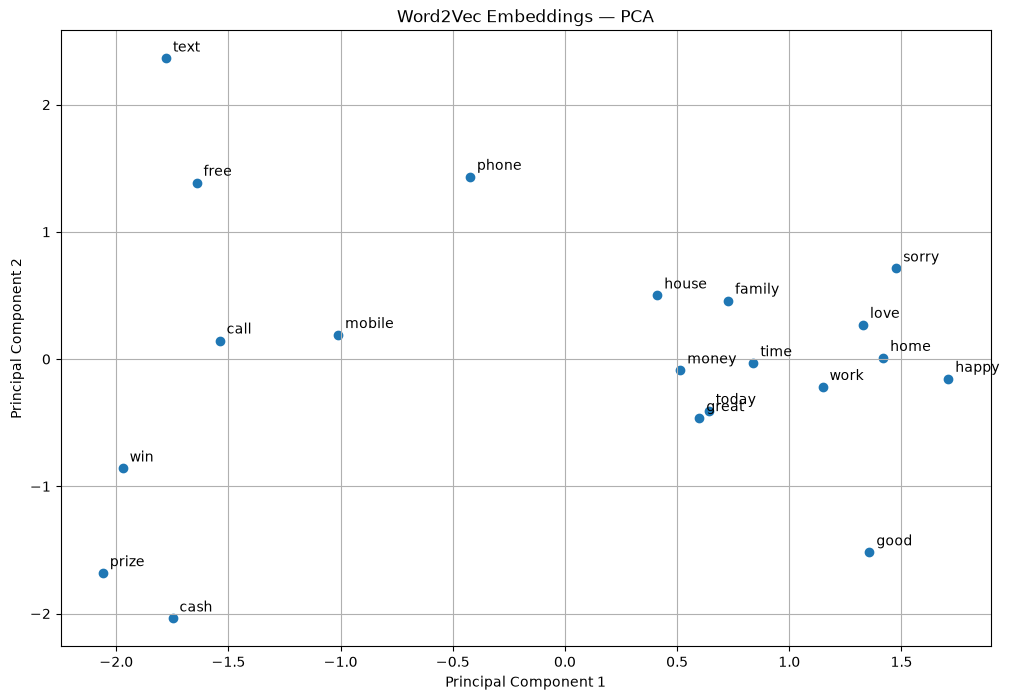

In [48]:
plt.figure(figsize=(12, 8))

plt.scatter(
    vectors_2d[:, 0],
    vectors_2d[:, 1]
)

for i, word in enumerate(words):
    plt.annotate(
        word,
        (vectors_2d[i, 0], vectors_2d[i, 1]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title("Word2Vec Embeddings — PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

## t-SNE

In [49]:
from sklearn.manifold import TSNE

In [50]:
tsne = TSNE(
    n_components=2,
    perplexity=5,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

vectors_tsne = tsne.fit_transform(word_vectors)

print("Reduced shape:", vectors_tsne.shape)

Reduced shape: (20, 2)


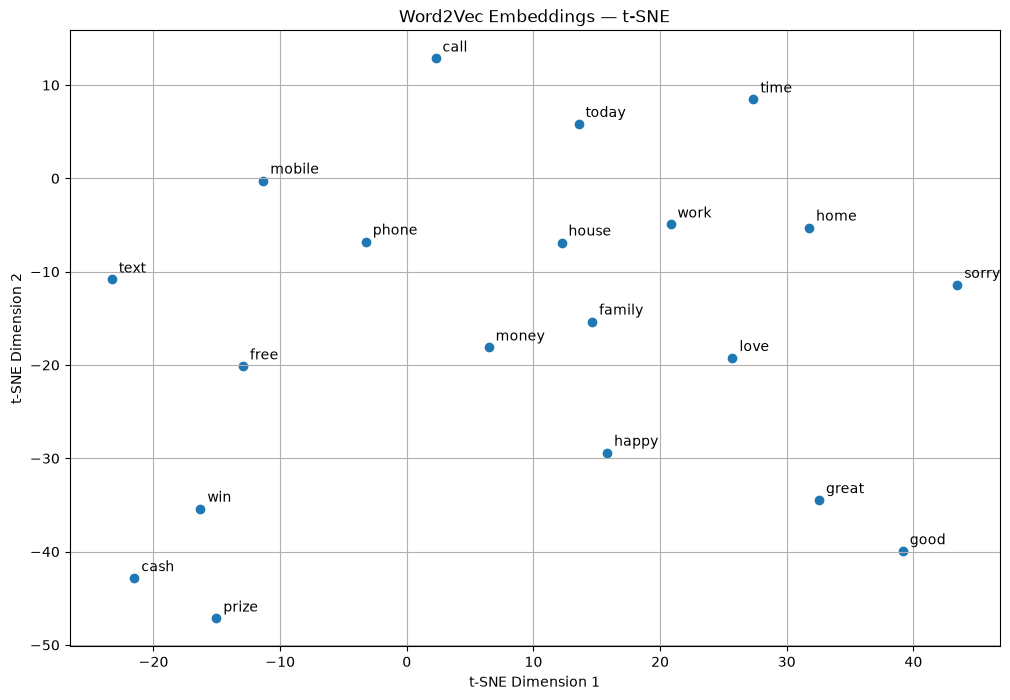

In [51]:
plt.figure(figsize=(12, 8))

plt.scatter(
    vectors_tsne[:, 0],
    vectors_tsne[:, 1]
)

for i, word in enumerate(words):
    plt.annotate(
        word,
        (vectors_tsne[i, 0], vectors_tsne[i, 1]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title("Word2Vec Embeddings — t-SNE")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(True)
plt.show()

# TF-IDF vs Word2Vec for Spam Detection

## Step 11 — Build the TF-IDF Baseline

In [52]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train_clean)
X_test_tfidf = tfidf.transform(X_test_clean)

print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (4135, 5000)
Testing shape: (1034, 5000)


In [53]:
tfidf_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

tfidf_model.fit(X_train_tfidf, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [54]:
y_pred_tfidf = tfidf_model.predict(X_test_tfidf)

In [55]:
print(classification_report(
    y_test,
    y_pred_tfidf,
    target_names=["ham", "spam"]
))

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       903
        spam       0.99      0.74      0.85       131

    accuracy                           0.97      1034
   macro avg       0.98      0.87      0.91      1034
weighted avg       0.97      0.97      0.96      1034



In [56]:
tfidf_accuracy = accuracy_score(y_test, y_pred_tfidf)
tfidf_precision = precision_score(y_test, y_pred_tfidf)
tfidf_recall = recall_score(y_test, y_pred_tfidf)
tfidf_f1 = f1_score(y_test, y_pred_tfidf)

print(f"Accuracy : {tfidf_accuracy:.4f}")
print(f"Precision: {tfidf_precision:.4f}")
print(f"Recall   : {tfidf_recall:.4f}")
print(f"F1-score : {tfidf_f1:.4f}")

Accuracy : 0.9662
Precision: 0.9898
Recall   : 0.7405
F1-score : 0.8472


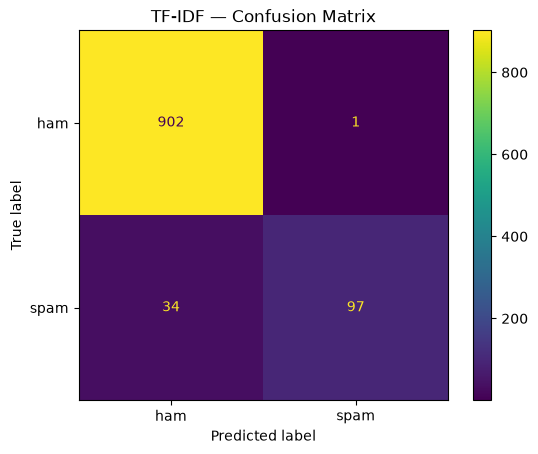

In [57]:
cm = confusion_matrix(y_test, y_pred_tfidf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["ham", "spam"]
)

disp.plot()
plt.title("TF-IDF — Confusion Matrix")
plt.show()

In [61]:
print(cm)

[[902   1]
 [ 34  97]]


## Step 12: Convert Messages to Word2Vec Embeddings

In [62]:
def message_to_vector(tokens, model):
    vectors = []

    for word in tokens:
        if word in model.wv:
            vectors.append(model.wv[word])

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

In [63]:
X_train_w2v = np.array([
    message_to_vector(tokens, word2vec_model)
    for tokens in train_tokens
])

X_test_w2v = np.array([
    message_to_vector(tokens, word2vec_model)
    for tokens in test_tokens
])

In [64]:
print("Training shape:", X_train_w2v.shape)
print("Testing shape:", X_test_w2v.shape)

Training shape: (4135, 100)
Testing shape: (1034, 100)


## Step 13: Train Logistic Regression Using Word2Vec

In [65]:
word2vec_classifier = LogisticRegression(
    max_iter=1000,
    random_state=42
)

word2vec_classifier.fit(X_train_w2v, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [66]:
y_pred_w2v = word2vec_classifier.predict(X_test_w2v)

## Step 14: Evaluate the Word2Vec Model

In [67]:
w2v_accuracy = accuracy_score(y_test, y_pred_w2v)
w2v_precision = precision_score(y_test, y_pred_w2v)
w2v_recall = recall_score(y_test, y_pred_w2v)
w2v_f1 = f1_score(y_test, y_pred_w2v)

print("Word2Vec Model Performance")
print("--------------------------")
print(f"Accuracy : {w2v_accuracy:.4f}")
print(f"Precision: {w2v_precision:.4f}")
print(f"Recall   : {w2v_recall:.4f}")
print(f"F1-score : {w2v_f1:.4f}")

Word2Vec Model Performance
--------------------------
Accuracy : 0.9797
Precision: 0.9583
Recall   : 0.8779
F1-score : 0.9163


In [68]:
print(classification_report(
    y_test,
    y_pred_w2v,
    target_names=["Ham", "Spam"]
))

              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99       903
        Spam       0.96      0.88      0.92       131

    accuracy                           0.98      1034
   macro avg       0.97      0.94      0.95      1034
weighted avg       0.98      0.98      0.98      1034



## Step 15: Word2Vec Confusion Matrix

In [69]:
cm_w2v = confusion_matrix(y_test, y_pred_w2v)

print("Confusion Matrix:")
print(cm_w2v)

Confusion Matrix:
[[898   5]
 [ 16 115]]


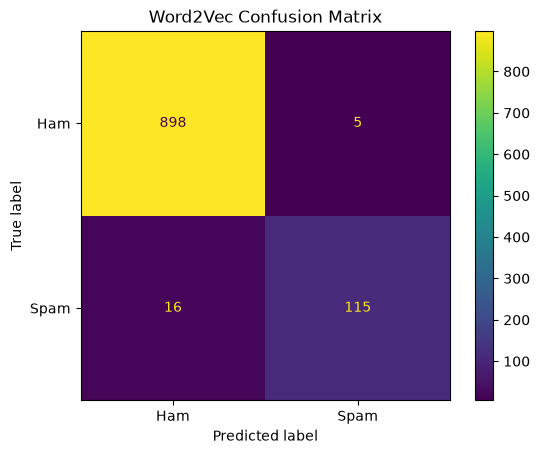

In [70]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_w2v,
    display_labels=["Ham", "Spam"]
)

disp.plot()
plt.title("Word2Vec Confusion Matrix")
plt.show()

## Step 16: Compare TF-IDF vs Word2Vec

In [72]:
comparison = pd.DataFrame({
    "Model": ["TF-IDF", "Word2Vec"],
    "Accuracy": [
        tfidf_accuracy,
        w2v_accuracy
    ],
    "Precision": [
        tfidf_precision,
        w2v_precision
    ],
    "Recall": [
        tfidf_recall,
        w2v_recall
    ],
    "F1-score": [
        tfidf_f1,
        w2v_f1
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-score
0,TF-IDF,0.966151,0.989796,0.740458,0.847162
1,Word2Vec,0.979691,0.958333,0.877863,0.916335


## Step 17: Visualize the Comparison

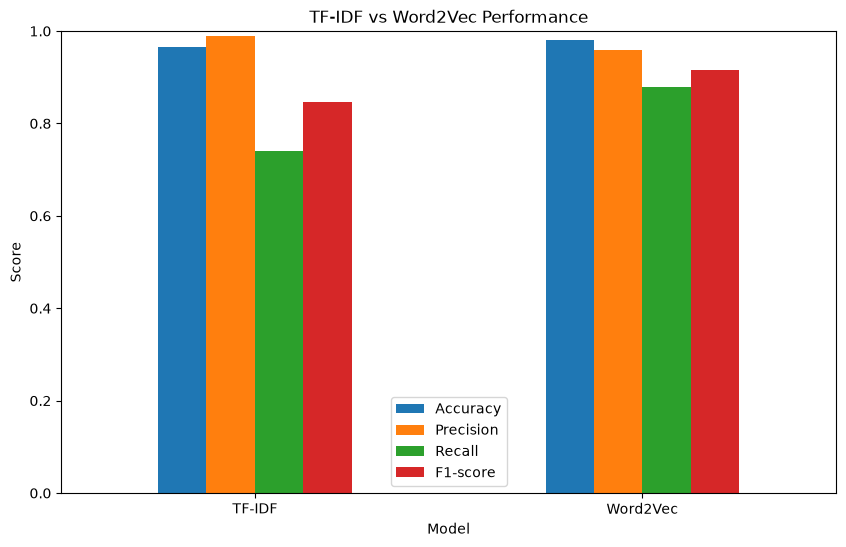

In [73]:
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("TF-IDF vs Word2Vec Performance")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()

## Step 18: Final Analysis

### Conclusion

The TF-IDF and Word2Vec approaches were compared using Logistic Regression for SMS spam detection.

The Word2Vec model achieved an accuracy of 97.97%, which was higher than the 96.62% achieved by the TF-IDF model. Word2Vec also achieved a substantially higher recall of 87.79% compared with 74.05% for TF-IDF, meaning that it was able to identify a larger proportion of the actual spam messages.

The F1-score also improved from 84.72% with TF-IDF to 91.63% with Word2Vec. This indicates a better balance between precision and recall. However, TF-IDF achieved a higher precision of 98.98%, compared with 95.83% for Word2Vec.

Overall, Word2Vec performed better on this spam detection task based on accuracy, recall, and F1-score. Although TF-IDF achieved higher precision, the stronger recall and F1-score of Word2Vec make it the better overall approach for this dataset.